In [106]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np 
import seaborn as sns 
from datetime import date as dt

In [107]:
df = pd.read_csv("../data/swap_transactions.csv",parse_dates=["timestamp"])
df_swaps = pd.read_csv("../data/stations.csv",parse_dates=["opening_date"])

In [108]:
stations_df = df_swaps.copy()

In [109]:
transactions_df = df.copy()

In [110]:
stations_df

,station_id,station_name,district,latitude,longitude,capacity,opening_date
0,ST001,Adenta,Adenta Municipal,5.7049,-0.1682,24,2024-01-15
1,ST002,Haatso,Ga East,5.6704,-0.1988,20,2024-03-01
2,ST003,Spintex,Tema West,5.6256,-0.1024,28,2023-11-10
3,ST004,Kaneshie,Accra Metro,5.5611,-0.2347,24,2024-02-05
4,ST005,Abelenkpe,Ayawaso West,5.6096,-0.1967,20,2024-04-18


In [111]:
transactions_df

,swap_id,timestamp,station_id,battery_soc_returned,battery_soc_issued,wait_minutes,swap_duration_minutes,batteries_available_before_swap,station_status,downtime_minutes,payment_amount,payment_method,motorcycle_type,service_success
0,SW000001,2026-01-01 06:02:33,ST001,34.1,93.2,0.6,4.5,12,Operational,0,35.45,Mobile Money,Standard,True
1,SW000002,2026-01-01 06:32:12,ST004,41.2,95.9,2.8,3.7,16,Operational,0,38.98,Mobile Money,Delivery,True
2,SW000003,2026-01-01 06:46:12,ST005,24.9,85.8,1.2,2.9,15,Operational,0,32.24,Mobile Money,Standard,True
3,SW000004,2026-01-01 06:50:15,ST004,19.6,91.2,9.6,4.5,24,Operational,0,38.84,Mobile Money,Delivery,True
4,SW000005,2026-01-01 06:59:01,ST004,31.7,95.5,4.7,3.2,19,Operational,0,36.44,Mobile Money,Standard,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,SW029996,2026-06-30 22:42:16,ST002,32.5,100.0,1.9,4.4,8,Operational,0,38.97,Mobile Money,Delivery,True
29996,SW029997,2026-06-30 22:54:17,ST003,5.8,96.6,4.0,3.2,1,Operational,0,36.70,Mobile Money,Standard,True
29997,SW029998,2026-06-30 23:16:49,ST004,17.6,98.3,5.5,4.2,15,Operational,0,37.16,Mobile Money,Delivery,True
29998,SW029999,2026-06-30 23:21:50,ST002,20.6,95.5,1.8,4.3,20,Operational,0,34.94,Mobile Money,Standard,True


In [112]:
transactions_df.columns

Index(['swap_id', 'timestamp', 'station_id', 'battery_soc_returned',
       'battery_soc_issued', 'wait_minutes', 'swap_duration_minutes',
       'batteries_available_before_swap', 'station_status', 'downtime_minutes',
       'payment_amount', 'payment_method', 'motorcycle_type',
       'service_success'],
      dtype='object')

In [113]:
transactions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   swap_id                          30000 non-null  object        
 1   timestamp                        30000 non-null  datetime64[ns]
 2   station_id                       30000 non-null  object        
 3   battery_soc_returned             30000 non-null  float64       
 4   battery_soc_issued               30000 non-null  float64       
 5   wait_minutes                     30000 non-null  float64       
 6   swap_duration_minutes            30000 non-null  float64       
 7   batteries_available_before_swap  30000 non-null  int64         
 8   station_status                   30000 non-null  object        
 9   downtime_minutes                 30000 non-null  int64         
 10  payment_amount                   30000 non-null  float64  

In [114]:
transactions_df.isna().sum()

swap_id                            0
timestamp                          0
station_id                         0
battery_soc_returned               0
battery_soc_issued                 0
wait_minutes                       0
swap_duration_minutes              0
batteries_available_before_swap    0
station_status                     0
downtime_minutes                   0
payment_amount                     0
payment_method                     0
motorcycle_type                    0
service_success                    0
dtype: int64

In [115]:
transactions_df["swap_id"].duplicated().sum()

np.int64(0)

In [116]:
transactions_df["station_id"].value_counts()

station_id
ST001    7912
ST003    6921
ST004    6196
ST002    4945
ST005    4026
Name: count, dtype: int64

In [117]:
transactions_df["timestamp"] = pd.to_datetime(transactions_df["timestamp"])

In [119]:
transactions_df["date"] = transactions_df["timestamp"].dt.date
transactions_df["hour"] = transactions_df["timestamp"].dt.hour
transactions_df["day"] = transactions_df["timestamp"].dt.day_name()
transactions_df["month"] = transactions_df["timestamp"].dt.month_name()

In [120]:
transactions_df[["timestamp","date","hour","day","month"]].head(3)

,timestamp,date,hour,day,month
0,2026-01-01 06:02:33,2026-01-01,6,Thursday,January
1,2026-01-01 06:32:12,2026-01-01,6,Thursday,January
2,2026-01-01 06:46:12,2026-01-01,6,Thursday,January


Calculating KPI

In [ ]:
#total swaps
total_swaps = transactions_df["swap_id"].nunique()
print(f"Total swaps are : {total_swaps}")

Total swaps are : 30000


In [125]:
#Total revenue
total_revenue = transactions_df["payment_amount"].sum()
print(f"Total Revenue made in GHS: {total_revenue}")

Total Revenue made in GHS: 1066165.08


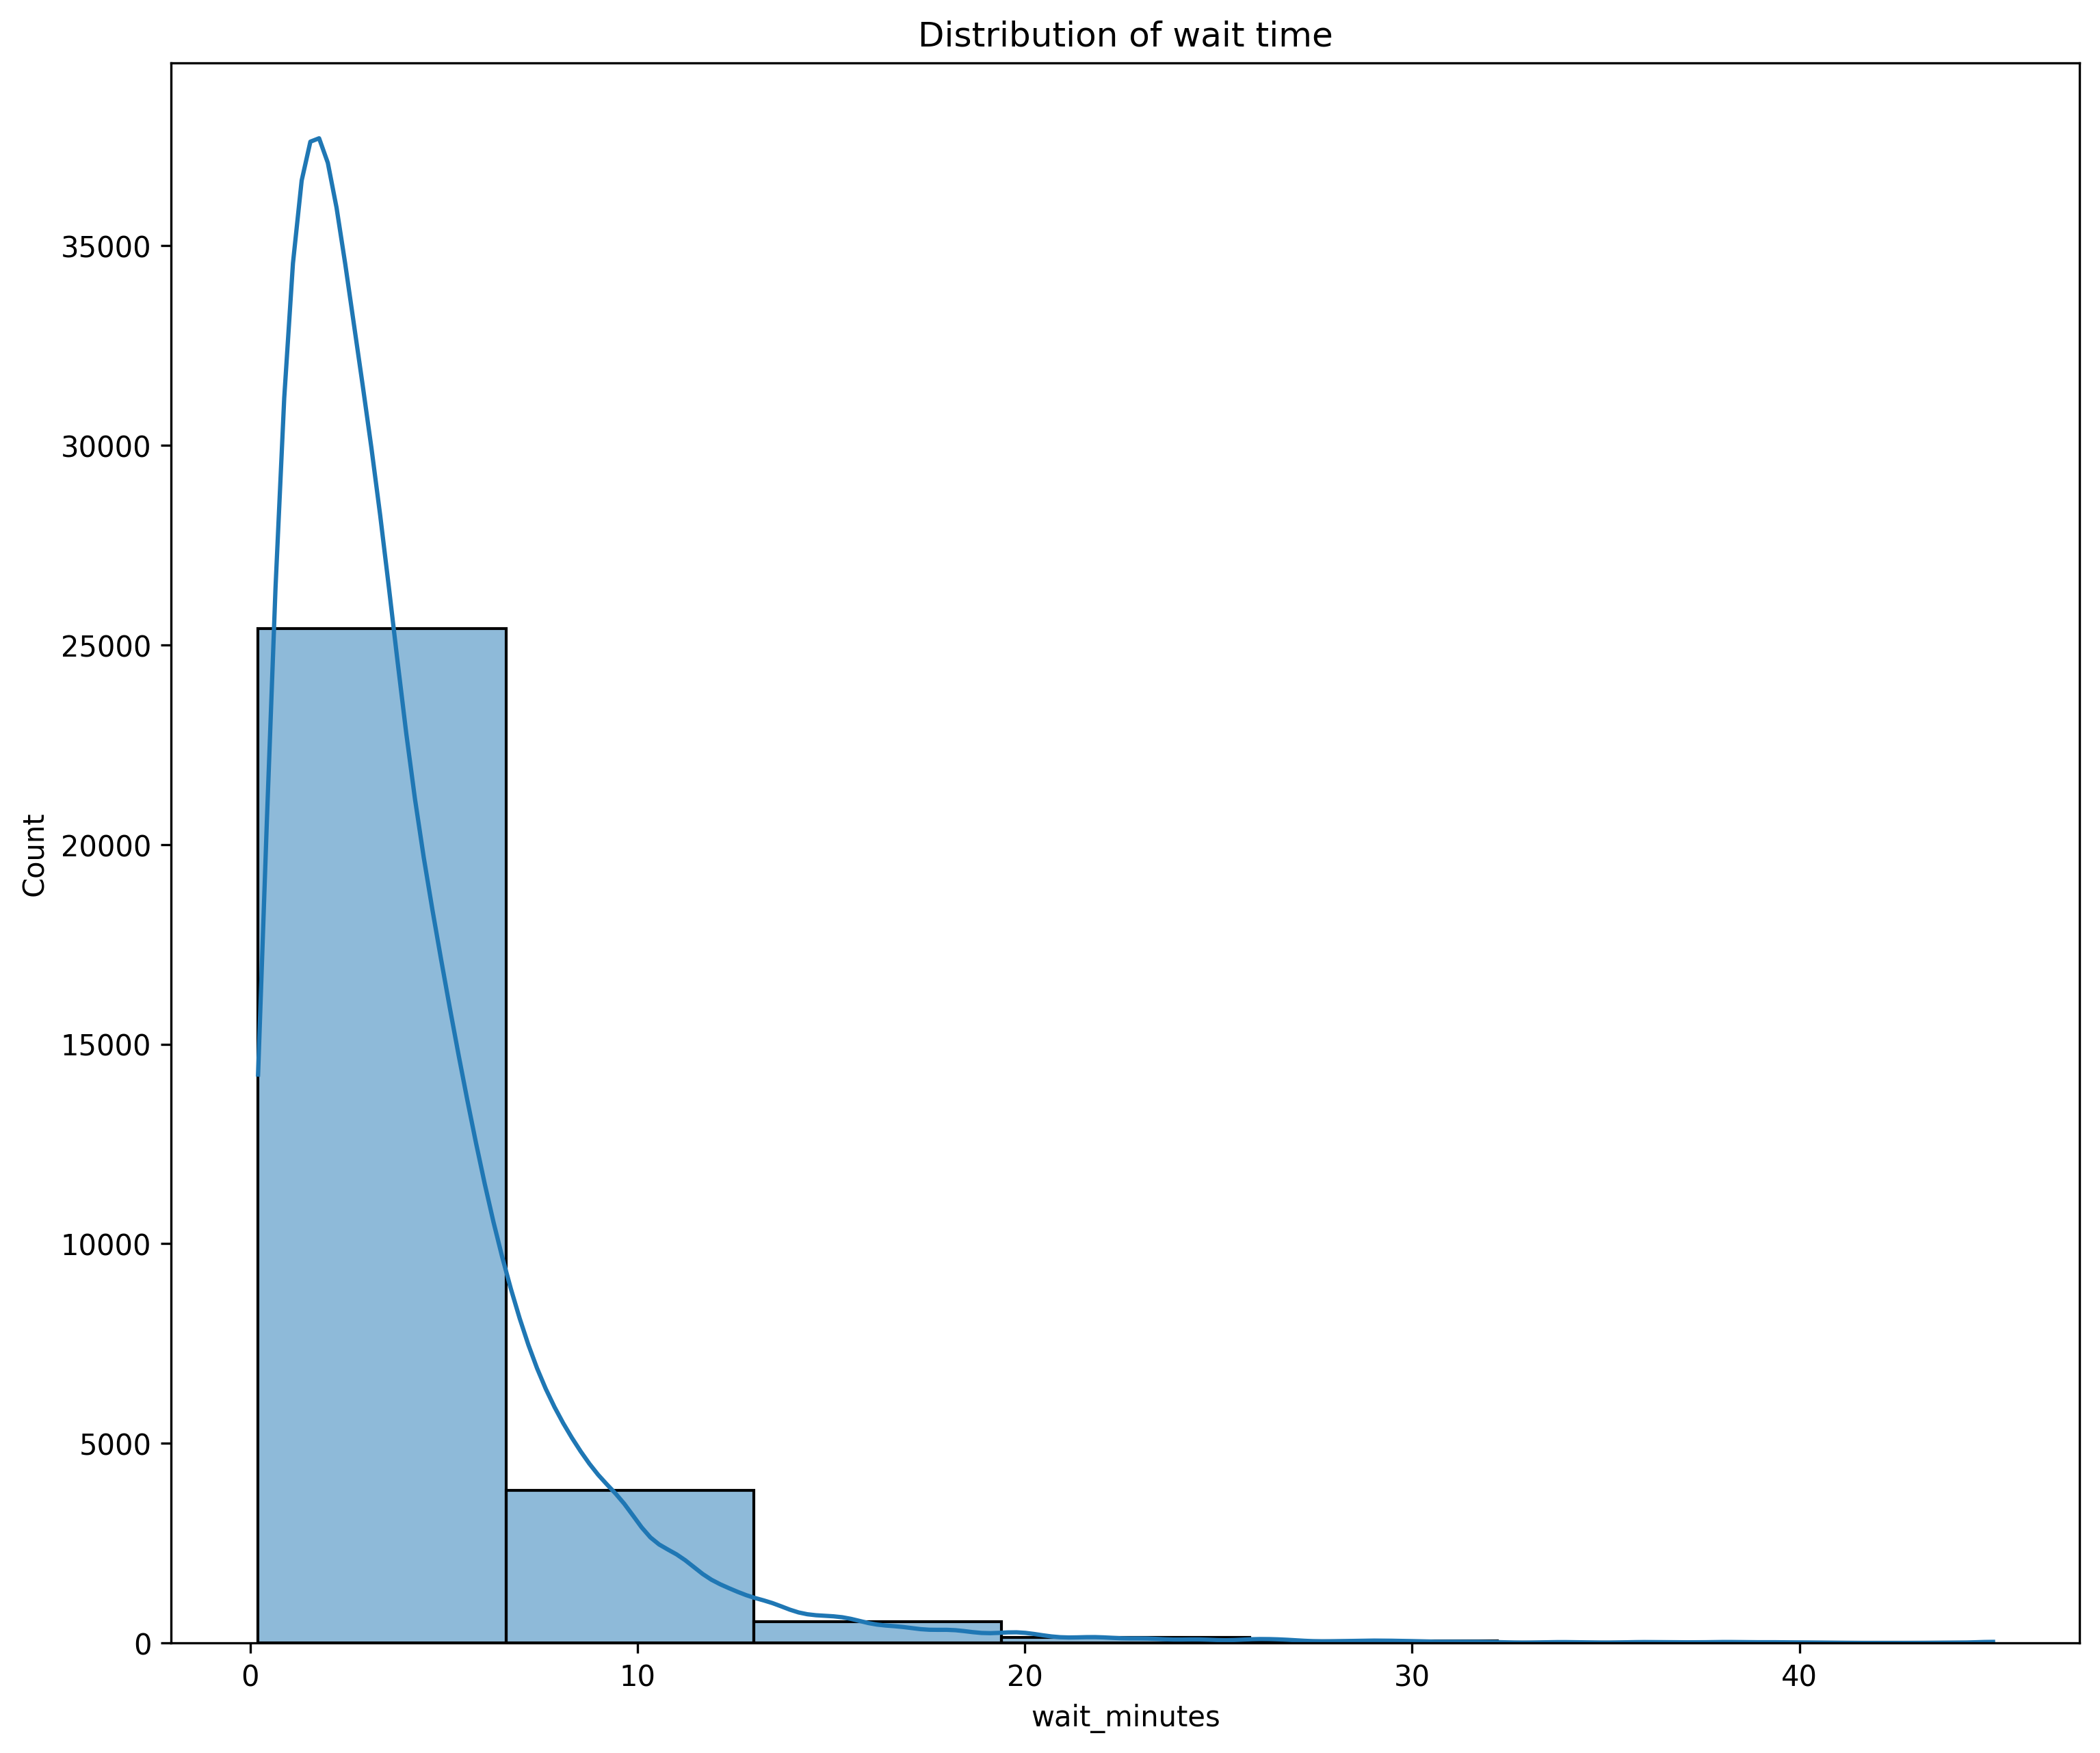

In [137]:
#distribution of wait time 
plt.figure(figsize=(12,10),dpi=300)
sns.histplot(transactions_df["wait_minutes"],bins=7,kde=True)
plt.title("Distribution of wait time")
plt.show()

In [ ]:
#   Average wait time
avg_wait_time = transactions_df["wait_minutes"].mean()
print("")